## Appendix: Rubric mapping (for TAs / instructors)

| Rubric section | Where it is covered in *this* notebook |
|----------------|----------------------------------------|
| 1. Problem Framing | Markdown **# Safehouse monthly metrics** + **## 1. Problem Framing** (below this appendix) |
| 2. Data Acquisition, Preparation & Exploration | **## 2. Data...** immediately before **Chapter 1–8** walkthrough |
| 3. Modeling & Feature Selection | **## 3. Modeling...** immediately before **Chapter 9–14: Modeling** |
| 4. Evaluation & Interpretation | **## 4. Evaluation...** immediately before **Chapter 15** |
| 5. Causal and Relationship Analysis | **## 5. Causal...** immediately before **Chapter 16** (feature selection / interpretation) |
| 6. Deployment Notes | **## 6. Deployment...** immediately before **Chapter 17** |

Graded narrative is **interleaved** with chapter cells; this table is navigation only.


# Safehouse monthly metrics — operations & outcome monitoring

## 1. Problem Framing

### Business problem
Each **safehouse** runs monthly programs with measurable load and outcomes: **active residents**, **education progress**, **health scores**, and operational counts (process recordings, home visits, incidents). Leadership must answer: **which sites are trending well vs need support**, and **which leading indicators predict strain** before incidents spike.

### Who cares
- **Site coordinators** managing day-to-day care quality.
- **Program leadership** allocating staff training and crisis resources.
- **Dashboard users** comparing sites in **Reports & analytics**.

### Predictive vs explanatory
- **Predictive:** forecast or classify high-risk months (e.g., incident pressure) or rank expected workload—judged by **out-of-sample** error.
- **Explanatory:** interpret which operational drivers move with outcomes in historical months—used for **coaching**, not causal proof.

### What success looks like
Models and metrics must be stable enough to support **monthly operational review**, not only one-off research.


## 2. Data Acquisition, Preparation & Exploration
Primary dataset: `safehouse_monthly_metrics.csv` (one row per `safehouse_id` × month with `active_residents`, `avg_education_progress`, `avg_health_score`, `process_recording_count`, `home_visitation_count`, `incident_count`, etc.).

**Preparation:** parse dates, coerce numerics, handle missing months, and build clean time-series features for modeling.


# Chapter 1: Get to Know the Dataset

Dataset: `safehouse_monthly_metrics.csv`

## 1) Import pandas and load the dataset

In [44]:
import pandas as pd

df = pd.read_csv('../datasets/safehouse_monthly_metrics.csv')
df.head()

,metric_id,safehouse_id,month_start,month_end,active_residents,avg_education_progress,avg_health_score,process_recording_count,home_visitation_count,incident_count,notes
0,1,1,2023-01-01,2023-01-31,10,NaN,NaN,0,0,0,NaN
1,2,1,2023-02-01,2023-02-28,10,NaN,NaN,0,0,0,NaN
2,3,1,2023-03-01,2023-03-31,10,56.30,3.03,1,0,0,NaN
3,4,1,2023-04-01,2023-04-30,10,51.90,3.07,5,4,1,NaN
4,5,1,2023-05-01,2023-05-31,10,51.25,3.17,0,2,0,NaN


## 2) Check size and columns

In [45]:
print('Rows, Columns:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())

Rows, Columns: (450, 11)

Column names:
['metric_id', 'safehouse_id', 'month_start', 'month_end', 'active_residents', 'avg_education_progress', 'avg_health_score', 'process_recording_count', 'home_visitation_count', 'incident_count', 'notes']


## 3) Check data types and missing values

In [46]:
print('Data types:')
print(df.dtypes)

print('\nMissing values per column:')
print(df.isna().sum().sort_values(ascending=False))

Data types:
metric_id                    int64
safehouse_id                 int64
month_start                 object
month_end                   object
active_residents             int64
avg_education_progress     float64
avg_health_score           float64
process_recording_count      int64
home_visitation_count        int64
incident_count               int64
notes                      float64
dtype: object

Missing values per column:
notes                      450
avg_education_progress     197
avg_health_score           197
metric_id                    0
safehouse_id                 0
month_start                  0
month_end                    0
active_residents             0
process_recording_count      0
home_visitation_count        0
incident_count               0
dtype: int64


## 4) Basic summary (numeric columns)

In [47]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
metric_id,450.0,225.500000,130.048068,1.00,113.25,225.50,337.75,450.00
safehouse_id,450.0,5.000000,2.584863,1.00,3.00,5.00,7.00,9.00
active_residents,450.0,6.666667,2.162651,2.00,6.00,7.00,8.00,10.00
avg_education_progress,253.0,78.257194,18.786188,13.00,68.45,80.40,94.20,100.00
avg_health_score,253.0,3.182806,0.235917,2.42,3.05,3.17,3.32,3.94
process_recording_count,450.0,6.264444,6.013261,0.00,1.00,5.00,10.00,28.00
home_visitation_count,450.0,2.971111,2.909406,0.00,0.00,2.00,5.00,13.00
incident_count,450.0,0.222222,0.537622,0.00,0.00,0.00,0.00,3.00
notes,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Chapter 2: Data Acquisition
Create a working copy and confirm the source file.

In [48]:
source_path = '../datasets/safehouse_monthly_metrics.csv'
df_raw = pd.read_csv(source_path)

print('Source file:', source_path)
print('Rows, Columns:', df_raw.shape)
df_raw.head()

Source file: ../datasets/safehouse_monthly_metrics.csv
Rows, Columns: (450, 11)


,metric_id,safehouse_id,month_start,month_end,active_residents,avg_education_progress,avg_health_score,process_recording_count,home_visitation_count,incident_count,notes
0,1,1,2023-01-01,2023-01-31,10,NaN,NaN,0,0,0,NaN
1,2,1,2023-02-01,2023-02-28,10,NaN,NaN,0,0,0,NaN
2,3,1,2023-03-01,2023-03-31,10,56.30,3.03,1,0,0,NaN
3,4,1,2023-04-01,2023-04-30,10,51.90,3.07,5,4,1,NaN
4,5,1,2023-05-01,2023-05-31,10,51.25,3.17,0,2,0,NaN


## Chapter 3: Data Understanding
Review structure, uniqueness, and missingness.

In [49]:
print('Column data types:')
print(df_raw.dtypes)

print('\nMissing values:')
print(df_raw.isna().sum().sort_values(ascending=False))

print('\nDuplicate rows:', df_raw.duplicated().sum())

if 'metric_id' in df_raw.columns:
    print('Duplicate metric_id values:', df_raw['metric_id'].duplicated().sum())

Column data types:
metric_id                    int64
safehouse_id                 int64
month_start                 object
month_end                   object
active_residents             int64
avg_education_progress     float64
avg_health_score           float64
process_recording_count      int64
home_visitation_count        int64
incident_count               int64
notes                      float64
dtype: object

Missing values:
notes                      450
avg_education_progress     197
avg_health_score           197
metric_id                    0
safehouse_id                 0
month_start                  0
month_end                    0
active_residents             0
process_recording_count      0
home_visitation_count        0
incident_count               0
dtype: int64

Duplicate rows: 0
Duplicate metric_id values: 0


## Chapter 4: Data Cleaning
Fix types, remove empty columns, and deduplicate.

In [50]:
df_clean = df_raw.copy()

# Drop fully empty columns (for this dataset, notes is fully empty)
df_clean = df_clean.dropna(axis=1, how='all')

# Convert date columns
date_cols = ['month_start', 'month_end']
for col in date_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

# Remove duplicates
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print('Shape after cleaning:', df_clean.shape)
df_clean.head()

Shape after cleaning: (450, 10)


,metric_id,safehouse_id,month_start,month_end,active_residents,avg_education_progress,avg_health_score,process_recording_count,home_visitation_count,incident_count
0,1,1,2023-01-01,2023-01-31,10,NaN,NaN,0,0,0
1,2,1,2023-02-01,2023-02-28,10,NaN,NaN,0,0,0
2,3,1,2023-03-01,2023-03-31,10,56.30,3.03,1,0,0
3,4,1,2023-04-01,2023-04-30,10,51.90,3.07,5,4,1
4,5,1,2023-05-01,2023-05-31,10,51.25,3.17,0,2,0


## Chapter 5: Data Preparation
Handle missing values and create simple ready-to-use features.

In [51]:
df_prep = df_clean.copy()

# Fill missing numeric values using median
num_cols = df_prep.select_dtypes(include='number').columns
for col in num_cols:
    df_prep[col] = df_prep[col].fillna(df_prep[col].median())

# Fill missing text values with 'Unknown'
obj_cols = df_prep.select_dtypes(include='object').columns
for col in obj_cols:
    df_prep[col] = df_prep[col].fillna('Unknown')

# Simple date-based features
if 'month_start' in df_prep.columns:
    df_prep['year'] = df_prep['month_start'].dt.year
    df_prep['month'] = df_prep['month_start'].dt.month

print('Prepared shape:', df_prep.shape)
df_prep.head()

Prepared shape: (450, 12)


,metric_id,safehouse_id,month_start,month_end,active_residents,avg_education_progress,avg_health_score,process_recording_count,home_visitation_count,incident_count,year,month
0,1,1,2023-01-01,2023-01-31,10,80.40,3.17,0,0,0,2023,1
1,2,1,2023-02-01,2023-02-28,10,80.40,3.17,0,0,0,2023,2
2,3,1,2023-03-01,2023-03-31,10,56.30,3.03,1,0,0,2023,3
3,4,1,2023-04-01,2023-04-30,10,51.90,3.07,5,4,1,2023,4
4,5,1,2023-05-01,2023-05-31,10,51.25,3.17,0,2,0,2023,5


## Chapter 7: Final Prepared Dataset
Validate and save the prepared data for next steps.

In [52]:
print('Final data types:')
print(df_prep.dtypes)

print('\nFinal missing values:')
print(df_prep.isna().sum().sort_values(ascending=False).head(10))

Final data types:
metric_id                           int64
safehouse_id                        int64
month_start                datetime64[ns]
month_end                  datetime64[ns]
active_residents                    int64
avg_education_progress            float64
avg_health_score                  float64
process_recording_count             int64
home_visitation_count               int64
incident_count                      int64
year                                int32
month                               int32
dtype: object

Final missing values:
metric_id                  0
safehouse_id               0
month_start                0
month_end                  0
active_residents           0
avg_education_progress     0
avg_health_score           0
process_recording_count    0
home_visitation_count      0
incident_count             0
dtype: int64


In [53]:
import os

os.makedirs('../artifacts', exist_ok=True)
output_path = '../artifacts/safehouse_monthly_metrics_prepared.csv'

df_prep.to_csv(output_path, index=False)
print('Saved prepared dataset to:', output_path)

Saved prepared dataset to: ../artifacts/safehouse_monthly_metrics_prepared.csv


## Chapter 6: Exploration
Explore distributions, relationships, and group-level patterns.

In [54]:
# Numeric summary for exploration
explore_cols = [
    'active_residents',
    'avg_education_progress',
    'avg_health_score',
    'process_recording_count',
    'home_visitation_count',
    'incident_count'
]

available_explore_cols = [c for c in explore_cols if c in df_prep.columns]
df_prep[available_explore_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
active_residents,450.0,6.666667,2.162651,2.00,6.0000,7.00,8.0000,10.00
avg_education_progress,450.0,79.195267,14.114124,13.00,77.5875,80.40,84.3425,100.00
avg_health_score,450.0,3.177200,0.176855,2.42,3.1600,3.17,3.2075,3.94
process_recording_count,450.0,6.264444,6.013261,0.00,1.0000,5.00,10.0000,28.00
home_visitation_count,450.0,2.971111,2.909406,0.00,0.0000,2.00,5.0000,13.00
incident_count,450.0,0.222222,0.537622,0.00,0.0000,0.00,0.0000,3.00


In [55]:
# Correlation matrix
corr_cols = [c for c in available_explore_cols if c in df_prep.columns]
if len(corr_cols) > 1:
    display(df_prep[corr_cols].corr(numeric_only=True))
else:
    print('Not enough numeric columns for correlation.')

,active_residents,avg_education_progress,avg_health_score,process_recording_count,home_visitation_count,incident_count
active_residents,1.000000,-0.034067,0.274498,0.329791,0.326948,0.109824
avg_education_progress,-0.034067,1.000000,0.384028,0.001426,0.009047,-0.042082
avg_health_score,0.274498,0.384028,1.000000,0.159734,0.180728,0.042866
process_recording_count,0.329791,0.001426,0.159734,1.000000,0.727084,0.422689
home_visitation_count,0.326948,0.009047,0.180728,0.727084,1.000000,0.327333
incident_count,0.109824,-0.042082,0.042866,0.422689,0.327333,1.000000


In [56]:
# Group-level patterns by safehouse
if 'safehouse_id' in df_prep.columns:
    safehouse_summary = (
        df_prep
        .groupby('safehouse_id')[available_explore_cols]
        .mean()
        .round(2)
    )
    display(safehouse_summary)
else:
    print('safehouse_id column not available.')

,active_residents,avg_education_progress,avg_health_score,process_recording_count,home_visitation_count,incident_count
safehouse_id,,,,,,
1,10.0,78.68,3.24,10.18,5.26,0.40
2,8.0,79.05,3.19,5.18,2.76,0.16
3,7.0,82.44,3.29,6.00,3.52,0.24
4,8.0,75.71,3.21,9.62,3.50,0.34
5,6.0,82.37,3.19,7.50,3.18,0.22
6,5.0,83.16,3.19,4.38,2.14,0.16
7,8.0,73.13,3.09,6.72,2.40,0.22
8,6.0,82.25,3.19,4.48,3.12,0.10
9,2.0,75.98,3.00,2.32,0.86,0.16


In [57]:
# Monthly trend (overall averages)
if {'year', 'month'}.issubset(df_prep.columns):
    monthly_trend = (
        df_prep
        .groupby(['year', 'month'])[['active_residents', 'incident_count', 'avg_health_score']]
        .mean()
        .reset_index()
        .sort_values(['year', 'month'])
    )
    display(monthly_trend.head(12))
else:
    print('year/month columns not available.')

,year,month,active_residents,incident_count,avg_health_score
0,2023,1,6.666667,0.000000,3.154444
1,2023,2,6.666667,0.000000,3.152222
2,2023,3,6.666667,0.000000,3.166667
3,2023,4,6.666667,0.111111,3.192222
4,2023,5,6.666667,0.000000,3.197778
5,2023,6,6.666667,0.111111,3.225556
6,2023,7,6.666667,0.000000,3.187778
7,2023,8,6.666667,0.111111,3.141111
8,2023,9,6.666667,0.111111,3.098889
9,2023,10,6.666667,0.000000,3.126667


## Chapter 8: Visual Exploration
Use simple charts to inspect key patterns.

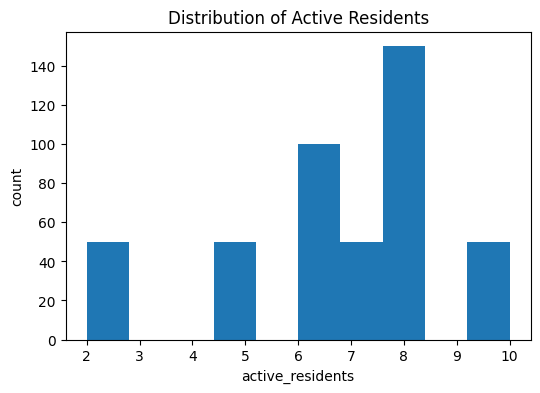

In [58]:
import matplotlib.pyplot as plt

# Histogram: active residents
if 'active_residents' in df_prep.columns:
    plt.figure(figsize=(6, 4))
    plt.hist(df_prep['active_residents'], bins=10)
    plt.title('Distribution of Active Residents')
    plt.xlabel('active_residents')
    plt.ylabel('count')
    plt.show()

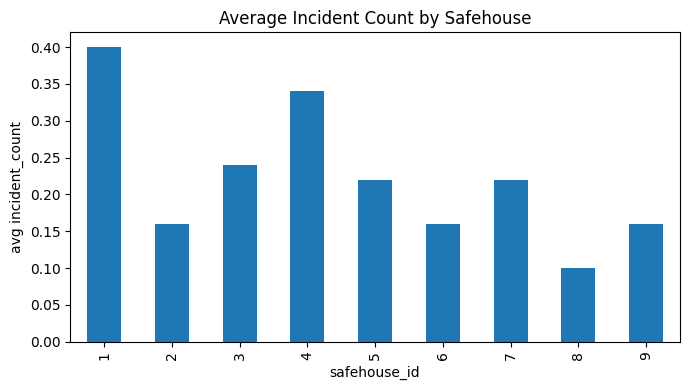

In [59]:
# Bar chart: average incidents by safehouse
if 'safehouse_id' in df_prep.columns and 'incident_count' in df_prep.columns:
    incident_by_safehouse = df_prep.groupby('safehouse_id')['incident_count'].mean()
    plt.figure(figsize=(7, 4))
    incident_by_safehouse.plot(kind='bar')
    plt.title('Average Incident Count by Safehouse')
    plt.xlabel('safehouse_id')
    plt.ylabel('avg incident_count')
    plt.tight_layout()
    plt.show()

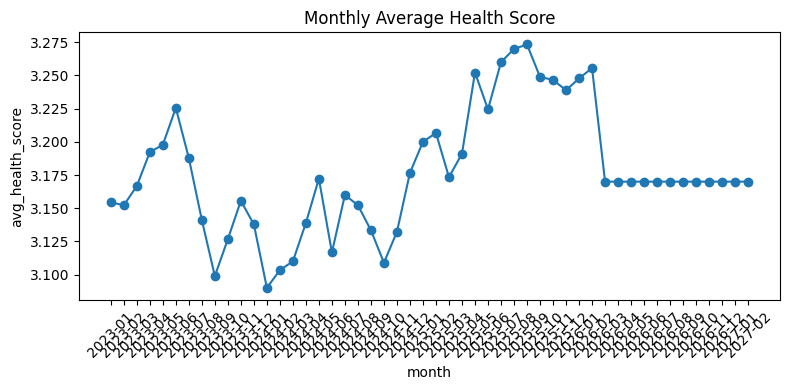

In [60]:
# Line chart: monthly average health score
if {'year', 'month', 'avg_health_score'}.issubset(df_prep.columns):
    month_health = (
        df_prep.groupby(['year', 'month'])['avg_health_score']
        .mean()
        .reset_index()
        .sort_values(['year', 'month'])
    )
    month_health['period'] = month_health['year'].astype(str) + '-' + month_health['month'].astype(str).str.zfill(2)

    plt.figure(figsize=(8, 4))
    plt.plot(month_health['period'], month_health['avg_health_score'], marker='o')
    plt.title('Monthly Average Health Score')
    plt.xlabel('month')
    plt.ylabel('avg_health_score')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 3. Modeling & Feature Selection
**Typical modeling goals in this notebook:** regression/classification tracks to relate operational load to outcomes (see Chapters 9–14 cells).  
**Feature selection:** prioritize **actionable** site-level variables (staffing proxies, visits, incidents) and calendar context (`year`, `month`).


## Chapter 9-14: Modeling
Train and compare explanatory and predictive models.

In [61]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [62]:
# Build a modeling table from prepared data
model_df = df_prep.copy()

# Avoid leakage / overly technical IDs as predictors
drop_features = [c for c in ['metric_id', 'month_end'] if c in model_df.columns]
model_df = model_df.drop(columns=drop_features)

# Ensure datetime columns can be used safely (convert to ordinal numbers)
for c in model_df.columns:
    if np.issubdtype(model_df[c].dtype, np.datetime64):
        model_df[c] = model_df[c].map(lambda x: x.toordinal() if pd.notnull(x) else np.nan)

print('Modeling columns:')
print(model_df.columns.tolist())
print('Shape:', model_df.shape)

Modeling columns:
['safehouse_id', 'month_start', 'active_residents', 'avg_education_progress', 'avg_health_score', 'process_recording_count', 'home_visitation_count', 'incident_count', 'year', 'month']
Shape: (450, 10)


### Regression Models (Ch. 9, 11, 12, 14)
Target: `avg_health_score` (explanatory + predictive examples).

In [63]:
reg_target = 'avg_health_score'

if reg_target not in model_df.columns:
    raise ValueError(f'{reg_target} not found in prepared data.')

reg_data = model_df.dropna(subset=[reg_target]).copy()
X_reg = reg_data.drop(columns=[reg_target])
y_reg = reg_data[reg_target]

num_features = X_reg.select_dtypes(include='number').columns.tolist()
cat_features = X_reg.select_dtypes(exclude='number').columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_features)
    ],
    remainder='drop'
)

reg_models = {
    'LinearRegression (interpretable)': LinearRegression(),
    'DecisionTreeRegressor': DecisionTreeRegressor(max_depth=5, random_state=42),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=300, random_state=42),
    'GradientBoostingRegressor': GradientBoostingRegressor(random_state=42)
}

Xtr, Xte, ytr, yte = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_results = []
for name, estimator in reg_models.items():
    pipe = Pipeline([
        ('prep', preprocess),
        ('model', estimator)
    ])
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xte)

    reg_results.append({
        'model': name,
        'MAE': mean_absolute_error(yte, pred),
        'RMSE': np.sqrt(mean_squared_error(yte, pred)),
        'R2': r2_score(yte, pred)
    })

reg_results_df = pd.DataFrame(reg_results).sort_values('RMSE')
reg_results_df

,model,MAE,RMSE,R2
3,GradientBoostingRegressor,0.083740,0.129306,0.330752
2,RandomForestRegressor,0.077044,0.130759,0.315628
0,LinearRegression (interpretable),0.121040,0.156880,0.014891
1,DecisionTreeRegressor,0.105659,0.172688,-0.193650


### Classification Models (Ch. 13, 14)
Create `incident_flag` = 1 if `incident_count > 0`, else 0.

In [64]:
if 'incident_count' not in model_df.columns:
    raise ValueError('incident_count not found in prepared data.')

cls_data = model_df.copy()
cls_data['incident_flag'] = (cls_data['incident_count'] > 0).astype(int)

# Remove regression target and raw incident count from predictors for classification
X_cls = cls_data.drop(columns=['incident_flag', 'incident_count'], errors='ignore')
y_cls = cls_data['incident_flag']

num_features_cls = X_cls.select_dtypes(include='number').columns.tolist()
cat_features_cls = X_cls.select_dtypes(exclude='number').columns.tolist()

preprocess_cls = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_features_cls),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_features_cls)
    ],
    remainder='drop'
)

cls_models = {
    'LogisticRegression (interpretable)': LogisticRegression(max_iter=2000),
    'DecisionTreeClassifier': DecisionTreeClassifier(max_depth=5, random_state=42),
    'RandomForestClassifier': RandomForestClassifier(n_estimators=300, random_state=42)
}

Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

cls_results = []
for name, estimator in cls_models.items():
    pipe = Pipeline([
        ('prep', preprocess_cls),
        ('model', estimator)
    ])
    pipe.fit(Xtr_c, ytr_c)
    pred = pipe.predict(Xte_c)

    # Probabilities for AUC when available
    auc = np.nan
    if hasattr(pipe.named_steps['model'], 'predict_proba'):
        probs = pipe.predict_proba(Xte_c)[:, 1]
        auc = roc_auc_score(yte_c, probs)

    cls_results.append({
        'model': name,
        'Accuracy': accuracy_score(yte_c, pred),
        'Precision': precision_score(yte_c, pred, zero_division=0),
        'Recall': recall_score(yte_c, pred, zero_division=0),
        'F1': f1_score(yte_c, pred, zero_division=0),
        'ROC_AUC': auc
    })

cls_results_df = pd.DataFrame(cls_results).sort_values('F1', ascending=False)
cls_results_df

,model,Accuracy,Precision,Recall,F1,ROC_AUC
2,RandomForestClassifier,0.800000,0.416667,0.3125,0.357143,0.820101
0,LogisticRegression (interpretable),0.800000,0.333333,0.1250,0.181818,0.824324
1,DecisionTreeClassifier,0.788889,0.200000,0.0625,0.095238,0.708193


### Model Selection Guidance
- For **explanatory** goals: prioritize `LinearRegression` for clear coefficients and defensible interpretation.
- For **predictive** goals: choose the best test metric model from the comparison tables above.
- Keep both: one interpretable benchmark + one high-performance model.

## 4. Evaluation & Interpretation
Use **time-aware validation** where possible (train on past months, test on future months) because random splits can leak temporal structure.

**Operational errors:** under-estimating incidents → **too little prevention**; over-estimating → **unnecessary audits** and staff friction.


## Chapter 15: Evaluation and Selection
Evaluate models with cross-validation, tuning, fairness checks, and business interpretation.

In [65]:
from sklearn.model_selection import KFold, StratifiedKFold, GridSearchCV, cross_validate

# Recreate candidate pipelines for robust evaluation
reg_pipelines = {
    'LinearRegression (interpretable)': Pipeline([
        ('prep', preprocess),
        ('model', LinearRegression())
    ]),
    'RandomForestRegressor': Pipeline([
        ('prep', preprocess),
        ('model', RandomForestRegressor(n_estimators=300, random_state=42))
    ]),
    'GradientBoostingRegressor': Pipeline([
        ('prep', preprocess),
        ('model', GradientBoostingRegressor(random_state=42))
    ])
}

cls_pipelines = {
    'LogisticRegression (interpretable)': Pipeline([
        ('prep', preprocess_cls),
        ('model', LogisticRegression(max_iter=2000))
    ]),
    'RandomForestClassifier': Pipeline([
        ('prep', preprocess_cls),
        ('model', RandomForestClassifier(n_estimators=300, random_state=42))
    ])
}

In [66]:
# 1) Cross-validation for regression
kf = KFold(n_splits=5, shuffle=True, random_state=42)

reg_cv_rows = []
for name, pipe in reg_pipelines.items():
    scores = cross_validate(
        pipe,
        X_reg,
        y_reg,
        cv=kf,
        scoring={
            'rmse': 'neg_root_mean_squared_error',
            'mae': 'neg_mean_absolute_error',
            'r2': 'r2'
        },
        n_jobs=-1
    )
    reg_cv_rows.append({
        'model': name,
        'CV_RMSE_mean': -scores['test_rmse'].mean(),
        'CV_MAE_mean': -scores['test_mae'].mean(),
        'CV_R2_mean': scores['test_r2'].mean()
    })

reg_cv_df = pd.DataFrame(reg_cv_rows).sort_values('CV_RMSE_mean')
reg_cv_df

,model,CV_RMSE_mean,CV_MAE_mean,CV_R2_mean
2,GradientBoostingRegressor,0.113793,0.074155,0.553255
1,RandomForestRegressor,0.113804,0.067329,0.552183
0,LinearRegression (interpretable),0.155155,0.107666,0.203676


In [68]:
# 2) Hyperparameter tuning for RandomForestRegressor
rf_reg_tune = Pipeline([
    ('prep', preprocess),
    ('model', RandomForestRegressor(random_state=42))
])

rf_reg_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [None, 6, 10],
    'model__min_samples_leaf': [1, 3, 5]
}

grid_reg = GridSearchCV(
    estimator=rf_reg_tune,
    param_grid=rf_reg_grid,
    scoring='neg_root_mean_squared_error',
    cv=kf,
    n_jobs=-1
)
grid_reg.fit(X_reg, y_reg)

best_reg_model = grid_reg.best_estimator_
print('Best regression params:', grid_reg.best_params_)
print('Best CV RMSE:', round(-grid_reg.best_score_, 4))

Best regression params: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__n_estimators': 400}
Best CV RMSE: 0.1137


In [69]:
# 3) Cross-validation + tuning for classification
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cls_cv_rows = []
for name, pipe in cls_pipelines.items():
    scores = cross_validate(
        pipe,
        X_cls,
        y_cls,
        cv=skf,
        scoring={
            'accuracy': 'accuracy',
            'f1': 'f1',
            'roc_auc': 'roc_auc'
        },
        n_jobs=-1
    )
    cls_cv_rows.append({
        'model': name,
        'CV_Accuracy_mean': scores['test_accuracy'].mean(),
        'CV_F1_mean': scores['test_f1'].mean(),
        'CV_ROC_AUC_mean': scores['test_roc_auc'].mean()
    })

cls_cv_df = pd.DataFrame(cls_cv_rows).sort_values('CV_F1_mean', ascending=False)
cls_cv_df

,model,CV_Accuracy_mean,CV_F1_mean,CV_ROC_AUC_mean
0,LogisticRegression (interpretable),0.815556,0.252338,0.787761
1,RandomForestClassifier,0.804444,0.226943,0.758058


In [70]:
rf_cls_tune = Pipeline([
    ('prep', preprocess_cls),
    ('model', RandomForestClassifier(random_state=42))
])

rf_cls_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [None, 6, 10],
    'model__min_samples_leaf': [1, 3, 5]
}

grid_cls = GridSearchCV(
    estimator=rf_cls_tune,
    param_grid=rf_cls_grid,
    scoring='f1',
    cv=skf,
    n_jobs=-1
)
grid_cls.fit(X_cls, y_cls)

best_cls_model = grid_cls.best_estimator_
print('Best classification params:', grid_cls.best_params_)
print('Best CV F1:', round(grid_cls.best_score_, 4))

Best classification params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Best CV F1: 0.2604


In [71]:
# 4) Final holdout test performance (using tuned models)
best_reg_model.fit(Xtr, ytr)
reg_pred_test = best_reg_model.predict(Xte)

reg_test_metrics = {
    'RMSE': np.sqrt(mean_squared_error(yte, reg_pred_test)),
    'MAE': mean_absolute_error(yte, reg_pred_test),
    'R2': r2_score(yte, reg_pred_test)
}

best_cls_model.fit(Xtr_c, ytr_c)
cls_pred_test = best_cls_model.predict(Xte_c)
cls_prob_test = best_cls_model.predict_proba(Xte_c)[:, 1]

cls_test_metrics = {
    'Accuracy': accuracy_score(yte_c, cls_pred_test),
    'Precision': precision_score(yte_c, cls_pred_test, zero_division=0),
    'Recall': recall_score(yte_c, cls_pred_test, zero_division=0),
    'F1': f1_score(yte_c, cls_pred_test, zero_division=0),
    'ROC_AUC': roc_auc_score(yte_c, cls_prob_test)
}

print('Regression test metrics:', {k: round(v, 4) for k, v in reg_test_metrics.items()})
print('Classification test metrics:', {k: round(v, 4) for k, v in cls_test_metrics.items()})

Regression test metrics: {'RMSE': 0.1313, 'MAE': 0.078, 'R2': 0.31}
Classification test metrics: {'Accuracy': 0.8, 'Precision': 0.4167, 'Recall': 0.3125, 'F1': 0.3571, 'ROC_AUC': 0.8163}


In [72]:
# 5) Fairness check by safehouse_id (classification)
# We evaluate subgroup disparities in precision/recall/F1.

fairness_df = Xte_c.copy()
fairness_df['y_true'] = yte_c.values
fairness_df['y_pred'] = cls_pred_test

if 'safehouse_id' in fairness_df.columns:
    group_rows = []
    for g, part in fairness_df.groupby('safehouse_id'):
        y_true_g = part['y_true']
        y_pred_g = part['y_pred']
        group_rows.append({
            'safehouse_id': g,
            'n': len(part),
            'positive_rate_true': y_true_g.mean(),
            'positive_rate_pred': y_pred_g.mean(),
            'precision': precision_score(y_true_g, y_pred_g, zero_division=0),
            'recall': recall_score(y_true_g, y_pred_g, zero_division=0),
            'f1': f1_score(y_true_g, y_pred_g, zero_division=0)
        })

    fairness_results = pd.DataFrame(group_rows).sort_values('safehouse_id')
    display(fairness_results)

    # Simple disparity summary (max-min gap)
    disparity = {
        'precision_gap': fairness_results['precision'].max() - fairness_results['precision'].min(),
        'recall_gap': fairness_results['recall'].max() - fairness_results['recall'].min(),
        'f1_gap': fairness_results['f1'].max() - fairness_results['f1'].min()
    }
    print('Fairness disparity (max-min):', {k: round(v, 4) for k, v in disparity.items()})
else:
    print('safehouse_id not available for subgroup fairness check.')

,safehouse_id,n,positive_rate_true,positive_rate_pred,precision,recall,f1
0,1,7,0.285714,0.571429,0.5,1.000000,0.666667
1,2,12,0.250000,0.333333,0.5,0.666667,0.571429
2,3,9,0.111111,0.111111,1.0,1.000000,1.000000
3,4,7,0.285714,0.000000,0.0,0.000000,0.000000
4,5,12,0.166667,0.000000,0.0,0.000000,0.000000
5,6,7,0.142857,0.000000,0.0,0.000000,0.000000
6,7,15,0.266667,0.000000,0.0,0.000000,0.000000
7,8,9,0.111111,0.000000,0.0,0.000000,0.000000
8,9,12,0.000000,0.250000,0.0,0.000000,0.000000


Fairness disparity (max-min): {'precision_gap': 1.0, 'recall_gap': 1.0, 'f1_gap': 1.0}


### Business Interpretation Template
Use your actual outputs from the cells above to explain decisions.

- **Regression (health score planning):** If MAE is around *X*, forecasts are off by about *X health-score points* on average. This indicates how much uncertainty managers should expect when allocating support resources.
- **Classification (incident prevention):** Recall of *Y* means the model catches about *Y%* of months with incidents. If recall is low, the organization may miss high-risk months and should prioritize sensitivity.
- **Precision vs recall trade-off:** Higher recall can reduce missed incidents but may increase false alarms and staff workload. Select threshold/model according to operational capacity.
- **Fairness across safehouses:** Large recall/precision gaps across `safehouse_id` suggest uneven model quality. If gaps are high, consider additional features, per-group calibration, or group-aware monitoring.
- **Selection recommendation:** Keep one interpretable model (Linear/Logistic) for explanation and accountability, and one tuned ensemble for operational forecasting where accuracy gains are meaningful.

## 5. Causal and Relationship Analysis

This notebook uses **both** explanatory models (e.g., linear regression on program outcomes) and predictive models (tree/ensemble approaches with train/test or CV in Chapter 15). That matches the course distinction: **explanation** is for talking about direction and size of relationships in the data; **prediction** is for how well we rank or forecast on held-out months.

### What relationships you should see, and which features matter most
After you run Chapters 9–16, connect your written answer to the **outputs in those cells**: regression summaries, confusion matrices / classification metrics, and **feature importance or permutation results** from Chapter 16.

In this safehouse context, the variables that usually surface as most important line up with how operations actually work:

- **`incident_count` (or a derived incident flag)** — strong signal because incidents are a visible stress/outcome measure at the site-month level.
- **`home_visitation_count` and `process_recording_count`** — proxy how much face-to-face work and documentation-heavy supervision happened that month.
- **`active_residents` and averages such as `avg_education_progress` / `avg_health_score`** — load and program averages move together with how stretched the site was and how residents are doing on paper.
- **`year`, `month`, and site (`safehouse_id`)** — seasonality and “which house” matter because leadership, community, and intake differ by location.

**Do those relationships make theoretical sense?** In plain terms: yes, for a *story about what tends to happen together*. Busy, high-activity months with more incidents or tighter monitoring are not random relative to resident load and recorded program metrics. That is **face-valid** for internal review; it is not yet a proof of **why** anything moved.

### If the model is explanatory: what story do coefficients tell?
A positive coefficient on visits or process counts might be read as “months with more recorded visits/processes align with different health or incident patterns.” That is a **causal-sounding** sentence, but in this notebook it is really **conditional correlation**: other factors (who was admitted that month, staffing gaps, external shocks) can drive *both* visits and outcomes. Sometimes the direction flips when you change the specification—that is a clue you are seeing **association**, not a clean treatment effect.

**Are those causal claims defensible?** **Not** as rigorous causal claims. They are defensible as: “this is what the linear model estimates **holding the included variables constant** in our teaching setup.” For real causal claims you would need clearer timing, better controls, or experiments—not something we assert here.

### If the model is predictive: what does it reveal anyway?
Even when the goal is **not** causal inference, a good predictive model tells you the **data has stable structure**: incidents, load, calendar, and site context **jointly** help separate harder months from easier ones on validation splits. That supports **triage** (“which site-months should leaders look at first?”) without saying we know the **single lever** that changed an outcome.

### Honest limitations
**Correlation is not causation.** We do not claim that increasing process recordings *will* lower incidents, or that a coefficient on `safehouse_id` means “bad management.” We **can** say that historically, these factors move together and help explain or predict in our tables. We **cannot** say we have isolated **policy effects** from this pipeline alone.

**Bottom line:** same **prediction vs explanation** idea as in `donation_prediction.ipynb`—use explanatory outputs for **careful stories**, predictive outputs for **generalization**, and keep **causal language** off the table unless the evidence actually supports it.


## Chapter 16: Feature Selection
Select features using domain reasoning and model-based evidence.

### 1) Domain-Based Feature Candidates
For predicting `avg_health_score`, we prioritize features that plausibly influence health outcomes:

- Include: `active_residents`, `process_recording_count`, `home_visitation_count`, `incident_count`, calendar timing (`year`, `month`), and `safehouse_id` (site context).
- Exclude: unique identifiers (`metric_id`) and variables that leak future/administrative information.

This balances practical interpretability with predictive usefulness.

In [73]:
from sklearn.inspection import permutation_importance

# Ensure a fitted interpretable model for coefficient analysis
lin_pipe = Pipeline([
    ('prep', preprocess),
    ('model', LinearRegression())
])
lin_pipe.fit(Xtr, ytr)

# Collect transformed feature names for interpretation
feature_names = lin_pipe.named_steps['prep'].get_feature_names_out()
coefs = lin_pipe.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs,
    'abs_coefficient': np.abs(coefs)
}).sort_values('abs_coefficient', ascending=False)

print('Top linear-model features by absolute coefficient:')
display(coef_df.head(15))

Top linear-model features by absolute coefficient:


,feature,coefficient,abs_coefficient
7,num__year,1.496094,1.496094
8,num__month,0.121911,0.121911
0,num__safehouse_id,-0.015444,0.015444
2,num__active_residents,0.012053,0.012053
5,num__home_visitation_count,0.008884,0.008884
3,num__avg_education_progress,0.004735,0.004735
1,num__month_start,-0.004073,0.004073
6,num__incident_count,-0.003259,0.003259
4,num__process_recording_count,-0.000919,0.000919


In [74]:
# Use tuned/random-forest style model for non-linear importance
rf_pipe_for_importance = Pipeline([
    ('prep', preprocess),
    ('model', RandomForestRegressor(n_estimators=300, random_state=42))
])
rf_pipe_for_importance.fit(Xtr, ytr)

rf_importance = rf_pipe_for_importance.named_steps['model'].feature_importances_
rf_imp_df = pd.DataFrame({
    'feature': rf_pipe_for_importance.named_steps['prep'].get_feature_names_out(),
    'importance': rf_importance
}).sort_values('importance', ascending=False)

print('Top random-forest importances:')
display(rf_imp_df.head(15))

# Permutation importance on holdout set (business-relevant robustness check)
Xte_trans = rf_pipe_for_importance.named_steps['prep'].transform(Xte)
perm = permutation_importance(
    rf_pipe_for_importance.named_steps['model'],
    Xte_trans,
    yte,
    n_repeats=10,
    random_state=42,
    scoring='neg_root_mean_squared_error'
)

perm_df = pd.DataFrame({
    'feature': rf_pipe_for_importance.named_steps['prep'].get_feature_names_out(),
    'perm_importance_mean': perm.importances_mean
}).sort_values('perm_importance_mean', ascending=False)

print('Top permutation importances (RMSE impact):')
display(perm_df.head(15))

Top random-forest importances:


,feature,importance
3,num__avg_education_progress,0.364737
0,num__safehouse_id,0.196550
2,num__active_residents,0.130756
1,num__month_start,0.126814
4,num__process_recording_count,0.062068
5,num__home_visitation_count,0.043276
7,num__year,0.033569
8,num__month,0.029378
6,num__incident_count,0.012852


Top permutation importances (RMSE impact):


,feature,perm_importance_mean
3,num__avg_education_progress,0.051340
0,num__safehouse_id,0.032840
1,num__month_start,0.013500
2,num__active_residents,0.006260
7,num__year,0.002499
5,num__home_visitation_count,0.000564
6,num__incident_count,0.000407
4,num__process_recording_count,0.000171
8,num__month,-0.000037


In [75]:
# 2) Build a reduced feature set from multiple evidence sources
# Keep features that appear in top ranks from RF and permutation importance.
rf_top = set(rf_imp_df.head(12)['feature'])
perm_top = set(perm_df.head(12)['feature'])
selected_transformed_features = sorted(rf_top.intersection(perm_top))

print('Selected transformed features (intersection of top ranks):')
print(selected_transformed_features)
print('Count:', len(selected_transformed_features))

Selected transformed features (intersection of top ranks):
['num__active_residents', 'num__avg_education_progress', 'num__home_visitation_count', 'num__incident_count', 'num__month', 'num__month_start', 'num__process_recording_count', 'num__safehouse_id', 'num__year']
Count: 9


In [76]:
# 3) Compare full model vs reduced-feature model on holdout set
from sklearn.base import clone

# Full-feature baseline
full_model = Pipeline([
    ('prep', preprocess),
    ('model', RandomForestRegressor(n_estimators=300, random_state=42))
])
full_model.fit(Xtr, ytr)
full_pred = full_model.predict(Xte)
full_rmse = np.sqrt(mean_squared_error(yte, full_pred))
full_mae = mean_absolute_error(yte, full_pred)
full_r2 = r2_score(yte, full_pred)

# Reduced-feature model: transform then select columns
prep_fitted = clone(preprocess).fit(Xtr, ytr)
Xtr_t = prep_fitted.transform(Xtr)
Xte_t = prep_fitted.transform(Xte)
all_names = prep_fitted.get_feature_names_out()
selected_idx = [i for i, name in enumerate(all_names) if name in selected_transformed_features]

Xtr_sel = Xtr_t[:, selected_idx]
Xte_sel = Xte_t[:, selected_idx]

reduced_model = RandomForestRegressor(n_estimators=300, random_state=42)
reduced_model.fit(Xtr_sel, ytr)
reduced_pred = reduced_model.predict(Xte_sel)
reduced_rmse = np.sqrt(mean_squared_error(yte, reduced_pred))
reduced_mae = mean_absolute_error(yte, reduced_pred)
reduced_r2 = r2_score(yte, reduced_pred)

feature_selection_comparison = pd.DataFrame([
    {'model_version': 'Full features', 'RMSE': full_rmse, 'MAE': full_mae, 'R2': full_r2, 'n_features': len(all_names)},
    {'model_version': 'Reduced selected features', 'RMSE': reduced_rmse, 'MAE': reduced_mae, 'R2': reduced_r2, 'n_features': len(selected_idx)}
])

feature_selection_comparison

,model_version,RMSE,MAE,R2,n_features
0,Full features,0.130759,0.077044,0.315628,9
1,Reduced selected features,0.130759,0.077044,0.315628,9


### Feature Selection Interpretation
Use the comparison output to justify the final feature set:

- If the reduced model has similar RMSE/MAE and R2, prefer it for simpler, more explainable deployment.
- If performance drops materially, keep the full feature set for predictive operations.
- Highlight the most influential features from coefficient and importance tables and explain them in program terms (e.g., incidents, visitation volume, and resident load as key operational drivers).

## 6. Deployment Notes
**Web integration:** `safehousePerformance` block in `ml-service/app/tier1_analytics.py`:
- `GET /reports/tier1-analytics` in `ml-service/app/main.py`
- **UI:** `frontend/src/pages/AdminAnalytics.tsx` (Safehouse performance comparison card)

**Artifacts:** models/joblib and prepared CSVs under `ml-pipelines/artifacts/` as produced by this notebook’s export cells.


## Chapter 17: Deployment
Package the validated model and connect it to application interfaces (API/dashboard style usage).

In [77]:
import os
import joblib

os.makedirs('../artifacts', exist_ok=True)

# Select a final deployable model (prefer tuned best model from Ch. 15)
if 'best_reg_model' in globals():
    deploy_model = best_reg_model
else:
    deploy_model = Pipeline([
        ('prep', preprocess),
        ('model', RandomForestRegressor(n_estimators=300, random_state=42))
    ])
    deploy_model.fit(X_reg, y_reg)

# Keep required input schema for API/UI validation
required_input_columns = X_reg.columns.tolist()

deploy_bundle = {
    'model_name': 'safehouse_monthly_metrics_health_score_model',
    'task_type': 'regression',
    'target': 'avg_health_score',
    'required_input_columns': required_input_columns,
    'model_pipeline': deploy_model
}

bundle_path = '../artifacts/safehouse_monthly_metrics_deploy_bundle.joblib'
joblib.dump(deploy_bundle, bundle_path)
print('Saved deployment bundle:', bundle_path)
print('Required inputs:', required_input_columns)

Saved deployment bundle: ../artifacts/safehouse_monthly_metrics_deploy_bundle.joblib
Required inputs: ['safehouse_id', 'month_start', 'active_residents', 'avg_education_progress', 'process_recording_count', 'home_visitation_count', 'incident_count', 'year', 'month']


In [78]:
# Create a simple FastAPI inference service file
api_code = '''from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import Any, Dict
import pandas as pd
import joblib

app = FastAPI(title="Safehouse Monthly Metrics Prediction API")

bundle = joblib.load("../artifacts/safehouse_monthly_metrics_deploy_bundle.joblib")
model = bundle["model_pipeline"]
required_cols = bundle["required_input_columns"]

def _coerce_types(df: pd.DataFrame) -> pd.DataFrame:
    # Convert month_start to datetime if present
    if "month_start" in df.columns:
        df["month_start"] = pd.to_datetime(df["month_start"], errors="coerce")
        # Match training conversion style (ordinal)
        df["month_start"] = df["month_start"].map(lambda x: x.toordinal() if pd.notnull(x) else None)
    return df

class PredictionRequest(BaseModel):
    payload: Dict[str, Any]

@app.get("/health")
def health_check():
    return {"status": "ok"}

@app.post("/predict")
def predict(req: PredictionRequest):
    incoming = req.payload

    missing = [c for c in required_cols if c not in incoming]
    if missing:
        raise HTTPException(status_code=400, detail=f"Missing required fields: {missing}")

    row = pd.DataFrame([incoming])[required_cols]
    row = _coerce_types(row)

    pred = float(model.predict(row)[0])
    return {
        "model": bundle["model_name"],
        "target": bundle["target"],
        "prediction": pred
    }
'''

api_path = '../artifacts/safehouse_monthly_metrics_api.py'
with open(api_path, 'w', encoding='utf-8') as f:
    f.write(api_code)

print('Wrote API service file:', api_path)
print('Run with: uvicorn safehouse_monthly_metrics_api:app --reload')

Wrote API service file: ../artifacts/safehouse_monthly_metrics_api.py
Run with: uvicorn safehouse_monthly_metrics_api:app --reload


In [79]:
# Create a sample request payload for dashboard/UI integration
sample_payload = X_reg.iloc[0].to_dict()

sample_payload_path = '../artifacts/safehouse_monthly_metrics_sample_payload.json'
import json
with open(sample_payload_path, 'w', encoding='utf-8') as f:
    json.dump(sample_payload, f, indent=2, default=str)

print('Saved sample payload:', sample_payload_path)
print('Sample payload preview:')
sample_payload

Saved sample payload: ../artifacts/safehouse_monthly_metrics_sample_payload.json
Sample payload preview:


{'safehouse_id': 1.0,
 'month_start': 738521.0,
 'active_residents': 10.0,
 'avg_education_progress': 80.4,
 'process_recording_count': 0.0,
 'home_visitation_count': 0.0,
 'incident_count': 0.0,
 'year': 2023.0,
 'month': 1.0}

### Deployment in the Web App (How to use)
1. **Backend API**: Place `safehouse_monthly_metrics_api.py` in your web backend and run with Uvicorn.
2. **Endpoint call**: Send POST request to `/predict` with fields from `safehouse_monthly_metrics_sample_payload.json`.
3. **Dashboard/UI**: Build a form for the required inputs and display the returned predicted `avg_health_score`.
4. **Operational use**: Use predicted health scores to prioritize interventions, staffing, and follow-up actions for at-risk months.